In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sparrow import Protein

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
df = pd.read_csv('../Data/Figures_2-3-4/GOOSE_ChargedxPcount_kappa_library_measured.csv')
constructs_df = pd.read_csv('../Data/Figures_2-3-4/constructs_df.csv')

In [3]:
re_values = []
for seq in df['sequence']:
    try:
        re_values.append(Protein(seq).predictor.end_to_end_distance())
    except Exception as e:
        print(f"Error for sequence {seq[:10]}...: {e}")
        re_values.append(np.nan)

df['re'] = re_values

Error importing GPy.
 If trying to run parrot-optimize, make sure to use `pip install idptools-parrot[optimize]`


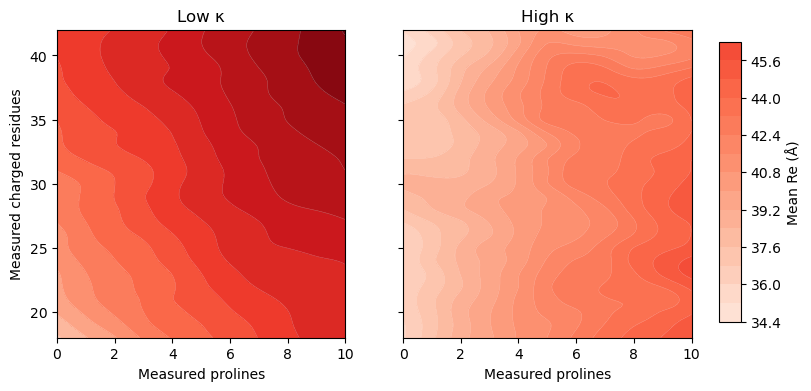

In [4]:
from scipy.interpolate import RBFInterpolator

df['mC'] = df['measured_charged'].round().astype(int)
df['mP'] = df['measured_Prolines'].round().astype(int)

grouped = df.groupby(['kappa_label', 'mC', 'mP']).agg(
    mean_re=('re', 'mean'),
).reset_index()

re_min = grouped['mean_re'].min()
re_max = grouped['mean_re'].max()

prolines_fine = np.linspace(grouped['mP'].min(), grouped['mP'].max(), 120)
charged_fine  = np.linspace(grouped['mC'].min(),  grouped['mC'].max(),  120)
gx, gy = np.meshgrid(prolines_fine, charged_fine)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True, sharex=True)
fig.subplots_adjust(right=0.83)
cax = fig.add_axes([0.86, 0.15, 0.025, 0.7])

for ax, label, title in zip(axes, ['lowK', 'highK'], ['Low κ', 'High κ']):
    sub = grouped[grouped['kappa_label'] == label]

    points = sub[['mP', 'mC']].values
    values = sub['mean_re'].values

    interp = RBFInterpolator(points, values, kernel='thin_plate_spline', smoothing=10)
    gz = interp(np.column_stack([gx.ravel(), gy.ravel()])).reshape(gx.shape)

    cf = ax.contourf(gx, gy, gz, levels=15, cmap='Reds', vmin=re_min, vmax=re_max)
    ax.contour( gx, gy, gz, levels=15, colors='white', linewidths=0.3, alpha=0.4)

    ax.set_ylim(18, 42)
    ax.set_title(title)
    ax.set_xlabel('Measured prolines')

axes[0].set_ylabel('Measured charged residues')
fig.colorbar(cf, cax=cax, label='Mean Re (Å)')

plt.show()

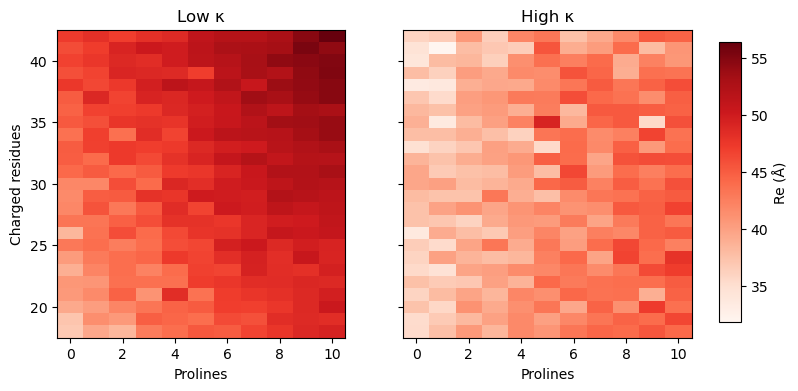

In [5]:
df['mC'] = df['measured_charged'].round().astype(int)
df['mP'] = df['measured_Prolines'].round().astype(int)

grouped = df.groupby(['kappa_label', 'mC', 'mP']).agg(
    mean_re=('re', 'mean'),
).reset_index()

re_min = grouped['mean_re'].min()
re_max = grouped['mean_re'].max()

p_vals = sorted(grouped['mP'].unique())
c_vals = sorted(grouped['mC'].unique())

p_edges = [p_vals[0] - 0.5] + [(p_vals[i] + p_vals[i+1])/2 for i in range(len(p_vals)-1)] + [p_vals[-1] + 0.5]
c_edges = [c_vals[0] - 0.5] + [(c_vals[i] + c_vals[i+1])/2 for i in range(len(c_vals)-1)] + [c_vals[-1] + 0.5]

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True, sharex=True)
fig.subplots_adjust(right=0.83)
cax = fig.add_axes([0.86, 0.15, 0.025, 0.7])

norm = plt.Normalize(vmin=re_min, vmax=re_max)

for ax, label, title in zip(axes, ['lowK', 'highK'], ['Low κ', 'High κ']):
    sub = grouped[grouped['kappa_label'] == label]

    Z = np.full((len(c_vals), len(p_vals)), np.nan)
    for _, row in sub.iterrows():
        ci = c_vals.index(row['mC'])
        pi = p_vals.index(row['mP'])
        Z[ci, pi] = row['mean_re']

    cf = ax.pcolormesh(p_edges, c_edges, Z, cmap='Reds', norm=norm)

    ax.set_ylim(17.5, 42.5)

    ax.set_title(title)
    ax.set_xlabel('Prolines')
    ax.set_xticks([v for v in p_vals if v % 2 == 0])
    ax.set_yticks([v for v in c_vals if v == 20 or (v > 20 and v % 5 == 0)])

axes[0].set_ylabel('Charged residues')
fig.colorbar(cf, cax=cax, label='Re (Å)')

#plt.savefig('/Users/trev/Downloads/ProlineTitration.svg')
plt.show()

In [6]:
from sparrow import Protein
from scipy import stats

# Make sure df (GOOSE library) has integer mP / mC columns
df['mP'] = df['measured_Prolines'].round().astype(int)
df['mC'] = df['measured_charged'].round().astype(int)

# Per-kappa sorted axes for orthogonal-neighbor lookup
p_vals = {k: sorted(df.loc[df['kappa_label'] == k, 'mP'].unique()) for k in ['lowK', 'highK']}
c_vals = {k: sorted(df.loc[df['kappa_label'] == k, 'mC'].unique()) for k in ['lowK', 'highK']}

def predicted_re_for_sequence(seq, library):
    prot = Protein(seq)
    L = len(seq)
    mP = int(round(prot.fraction_proline * L))
    mC = int(round(prot.FCR * L))
    kappa = prot.kappa
    klabel = 'lowK' if kappa < 0.5 else 'highK'

    pv, cv = p_vals[klabel], c_vals[klabel]
    pi = pv.index(mP) if mP in pv else min(range(len(pv)), key=lambda i: abs(pv[i] - mP))
    ci = cv.index(mC) if mC in cv else min(range(len(cv)), key=lambda i: abs(cv[i] - mC))

    # own cell + orthogonal neighbors (corners → 2; edges → 3; interior → 4)
    cells = [(pv[pi], cv[ci])]
    if pi > 0:                cells.append((pv[pi-1], cv[ci]))
    if pi < len(pv) - 1:      cells.append((pv[pi+1], cv[ci]))
    if ci > 0:                cells.append((pv[pi], cv[ci-1]))
    if ci < len(cv) - 1:      cells.append((pv[pi], cv[ci+1]))

    sub = library[library['kappa_label'] == klabel]
    mask = pd.Series(False, index=sub.index)
    for (p, c) in cells:
        mask |= (sub['mP'] == p) & (sub['mC'] == c)
    re_vals = sub.loc[mask, 're'].dropna()

    return {
        'mP': mP, 'mC': mC, 'kappa': kappa, 'kappa_label': klabel,
        'predicted_Re': re_vals.mean(),
        'predicted_Re_std': re_vals.std(),
        'predicted_Re_n': len(re_vals),
    }

# Apply to constructs_df
results = constructs_df['sequence'].apply(lambda s: pd.Series(predicted_re_for_sequence(s, df)))
for col in results.columns:
    constructs_df[col] = results[col]

In [46]:
def plot_ef_vs_predicted_re(constructs_df, construct_ids, figsize=(3, 4),
                            top_ef=0.45, bot_ef=0.15,
                            top_ree=10, bot_ree=80,
                            ylabel_ef='$E_f$',
                            ylabel_ree='Predicted $R_{e}$ (Å)'):
    plot_df = constructs_df[constructs_df['construct'].isin(construct_ids)].copy()
    plot_df['construct'] = pd.Categorical(plot_df['construct'],
                                          categories=construct_ids,
                                          ordered=True)
    plot_df = plot_df.sort_values('construct')

    fig, ax = plt.subplots(figsize=figsize)
    ax2 = ax.twinx()

    x_positions = np.arange(len(construct_ids))
    ef_x, ef_y, ree_x, ree_y = [], [], [], []
    construct_data_list = []

    for idx, (x_pos, cid) in enumerate(zip(x_positions, construct_ids)):
        row = plot_df[plot_df['construct'] == cid].iloc[0]

        ef_x.append(x_pos);  ef_y.append(row['Ef_cell'])
        ree_x.append(x_pos); ree_y.append(row['predicted_Re'])

        construct_data_list.append({
            'x_pos': x_pos,
            'ef_cell': row['Ef_cell'],
            'ef_cell_std': row['Ef_cell_std'],
            'n_wells': row['n_wells'],
            'ree': row['predicted_Re'],
            'ree_std': row['predicted_Re_std'],
            'n_ree': row['predicted_Re_n'],
        })

        ax.errorbar(x_pos, row['Ef_cell'], yerr=row['Ef_cell_std'],
                    fmt='o', color='green', markersize=11, capsize=7,
                    linewidth=2, capthick=2, alpha=0.8, ecolor='grey',
                    label='$E_f$ (cell)' if idx == 0 else '')
        ax2.errorbar(x_pos, row['predicted_Re'], yerr=row['predicted_Re_std'],
                     fmt='D', color='Orange', markersize=11, capsize=7,
                     linewidth=2, capthick=2, alpha=0.8, ecolor='grey',
                     label='Predicted $R_{ee}$' if idx == 0 else '')

    ax.plot(ef_x, ef_y,   color='grey', linestyle='-', linewidth=1.5, alpha=0.6, zorder=0)
    ax2.plot(ree_x, ree_y, color='grey', linestyle='-', linewidth=1.5, alpha=0.6, zorder=0)

    if len(construct_ids) == 2:
        d1, d2 = construct_data_list

        def p_to_symbol(p):
            if   p > 0.05:   return 'ns'
            elif p > 0.01:   return '*'
            elif p > 0.001:  return '**'
            elif p > 0.0001: return '***'
            else:            return '****'

        _, p_cell = stats.ttest_ind_from_stats(
            d1['ef_cell'], d1['ef_cell_std'], d1['n_wells'],
            d2['ef_cell'], d2['ef_cell_std'], d2['n_wells'], equal_var=True)
        sig_cell = p_to_symbol(p_cell)

        _, p_ree = stats.ttest_ind_from_stats(
            d1['ree'], d1['ree_std'], d1['n_ree'],
            d2['ree'], d2['ree_std'], d2['n_ree'], equal_var=True)
        sig_ree = p_to_symbol(p_ree)

        x1, x2 = d1['x_pos'], d2['x_pos']
        mid_x = (x1 + x2) / 2

        # Ef bracket below
        offset_cell = 0.04
        y_b1 = d1['ef_cell'] - d1['ef_cell_std']
        y_b2 = d2['ef_cell'] - d2['ef_cell_std']
        y_brk = min(y_b1, y_b2) - offset_cell
        y_l1 = y_brk + (y_b1 - y_brk) / 3
        y_l2 = y_brk + (y_b2 - y_brk) / 3
        ax.plot([x1, x1], [y_brk, y_l1], color='green', linewidth=1.5, alpha=0.8)
        ax.plot([x1, x2], [y_brk, y_brk], color='green', linewidth=1.5, alpha=0.8)
        ax.plot([x2, x2], [y_brk, y_l2], color='green', linewidth=1.5, alpha=0.8)
        ax.text(mid_x, y_brk - 0.01, sig_cell,
                fontsize=12, ha='center', va='top', color='green', fontweight='bold')

        # Re bracket (axis is inverted: bot_ree=80 at bottom, top_ree=10 at top)
        offset_ree = 5.0
        y_t1 = d1['ree'] - d1['ree_std']
        y_t2 = d2['ree'] - d2['ree_std']
        y_brk_r = min(y_t1, y_t2) - offset_ree
        y_l1_r = y_brk_r + (y_t1 - y_brk_r) / 3
        y_l2_r = y_brk_r + (y_t2 - y_brk_r) / 3
        ax2.plot([x1, x1], [y_brk_r, y_l1_r], color='Orange', linewidth=1.5, alpha=0.8)
        ax2.plot([x1, x2], [y_brk_r, y_brk_r], color='Orange', linewidth=1.5, alpha=0.8)
        ax2.plot([x2, x2], [y_brk_r, y_l2_r], color='Orange', linewidth=1.5, alpha=0.8)
        ax2.text(mid_x, y_brk_r, sig_ree,
                 fontsize=12, ha='center', va='bottom', color='Orange', fontweight='bold')

    ax.set_xlim(-0.5, len(construct_ids) - 0.5)
    ax.set_ylim(bot_ef, top_ef)
    ax2.set_ylim(bot_ree, top_ree)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.set_ylabel(ylabel_ef, fontsize=14, color='green')
    ax2.set_ylabel(ylabel_ree, fontsize=14, color='Orange')
    ax.tick_params(axis='y', colors='green')
    ax2.tick_params(axis='y', colors='Orange')
    ax.grid(True, alpha=0.3, axis='y')

    y_range = top_ef - bot_ef
    for i, cid in enumerate(construct_ids):
        ax.text(i, bot_ef + y_range * 0.01,
                f'#{cid}', ha='center', va='bottom',
                fontsize=13, fontweight='bold')

    plt.tight_layout()
    return fig, ax

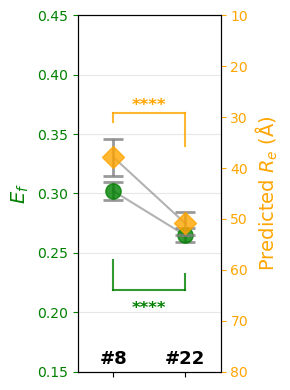

In [ ]:
fig, ax = plot_ef_vs_predicted_re(constructs_df, [8, 22])
#plt.savefig('/Users/trev/Downloads/8-22_predRe.svg')
plt.show()

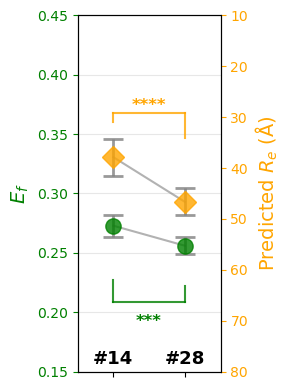

In [ ]:
fig, ax = plot_ef_vs_predicted_re(constructs_df, [14, 28])
#plt.savefig('/Users/trev/Downloads/14-28_predRe.svg')
plt.show()

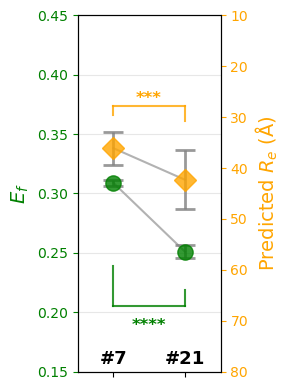

In [ ]:
fig, ax = plot_ef_vs_predicted_re(constructs_df, [7, 21])
#plt.savefig('/Users/trev/Downloads/7-21_predRe.svg')
plt.show()

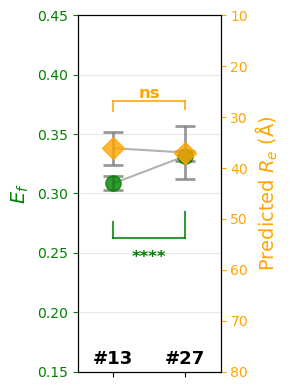

In [ ]:
fig, ax = plot_ef_vs_predicted_re(constructs_df, [13, 27])
#plt.savefig('/Users/trev/Downloads/13-27_predRe.svg')
plt.show()